# Neural Differential Equations in Julia

* A neural differential equation (NDE) is a differential equation

$$\frac{du}{dt} = f_\theta(u,t),$$
in which the right hand side $f_\theta$ is at least partially parametrized by an artificial neural network with parameters $\theta$.
  
* We can integrate these Neural Differential Equations numerically, like any other differential equation resulting in a trajectory $$\hat{\mathbf{u}}(\mathbf{x},t;\theta)$$

## Training NDEs

* Given some example trajectories $\mathbf{u}$ as training data, we can define a loss function like e.g. $$L(\theta)= \sum_{i_t,\mathbf{x}} ( \mathbf{u}(\mathbf{x},i_t) - \hat{\mathbf{u}}(\mathbf{x},i_t;\theta) )^2  + \gamma||\theta||$$

* What do we still need to train?

* For regular ANNs, we would do a gradient descent by computing $\nabla_\theta L$, but here we have a slightly different situation.

* Here $\hat{\mathbf{u}}(\mathbf{x},i_t;\theta)$ are trajectories, solutions of differential equations.

* How do we take a derivative of solutions of differential equations?

  1. We use automatic differentation (AD) directly through the differential equation solver
  2. We use adjoint sensivitiy analysis

### Automatic differentation

* Using AD is the same approach as the with regular neural networks.
* However, for this to work the solvers need to be written to be differentiable

### Adjoint Sensivity Analysis

* Adjoint sensitivity analysis has its origins in optimizing rocket trajectories, and has traditionally also many applications in climate models
* It formulates an augmented version of the original differential equation that enables us to compute the derivative of the solution with respect to initial conditions or parameters of the equation
* The augmented versions (or adjoints) are pre-defined in Julia in `SciMLSensitivity`

## Code Example

In the code example we set up a Neural Ordinary Equation to learn the Lotka-Volterra predator-prey model of populations of $x$ (e.g. foxes) and $y$ (e.g. hares)

$$\frac{dx}{dt} = \alpha x - \beta xy \\
\frac{dy}{dt} = -\gamma y + \delta xy.$$

In [1]:
import Pkg
Pkg.activate(".") # new empty env
Pkg.status()

  Activating project at `~/Nextcloud/EllisSummerSchool/scripts`


Status `~/Nextcloud/EllisSummerSchool/scripts/Project.toml`
  [052768ef] CUDA v5.8.3
  [587475ba] Flux v0.16.5
  [7e8f7934] MLDataDevices v1.11.2
  [56c15bac] NODEData v0.4.4 `https://github.com/maximilian-gelbrecht/NODEData.jl.git#main`
  [3bd65402] Optimisers v0.4.6
  [b1df2697] OrdinaryDiffEqTsit5 v1.5.0
  [91a5bcdd] Plots v1.40.19
  [1ed8b502] SciMLSensitivity v7.89.0
  [02a925ec] cuDNN v1.4.5


In [14]:
# install if needed, otherwise comment it out
#Pkg.add(["OrdinaryDiffEqTsit5", "Flux", "Plots", "MLDataDevices", "Optimisers", "SciMLSensitivity", "cuDNN", "CUDA"])
#Pkg.add(url="https://github.com/maximilian-gelbrecht/NODEData.jl.git") # helper package for dataloaders

    Updating git-repo `https://github.com/maximilian-gelbrecht/NODEData.jl.git`
   Resolving package versions...
   Installed ChunkCodecLibZstd ─ v1.0.0
   Installed ChunkCodecCore ──── v1.0.0
   Installed ChunkCodecLibZlib ─ v1.0.0
   Installed JLD2 ────────────── v0.6.1
    Updating `~/Nextcloud/EllisSummerSchool/scripts/Project.toml`
  [56c15bac] + NODEData v0.4.4 `https://github.com/maximilian-gelbrecht/NODEData.jl.git#main`
    Updating `~/Nextcloud/EllisSummerSchool/scripts/Manifest.toml`
  [70df07ce] + BracketingNonlinearSolve v1.3.0
  [0b6fb165] + ChunkCodecCore v1.0.0
  [4c0bbee4] + ChunkCodecLibZlib v1.0.0
  [55437552] + ChunkCodecLibZstd v1.0.0
  [da5c29d0] + EllipsisNotation v1.8.0
  [7d51a73a] + ExplicitImports v1.13.2
  [d4d017d3] + ExponentialUtilities v1.27.0
  [442a2c76] + FastGaussQuadrature v1.0.2
  [5789e2e9] + FileIO v1.17.0
  [c145ed77] + GenericSchur v0.5.5
  [033835bb] + JLD2 v0.6.1
  [87fe0de2] + LineSearch v0.1.4
  [bb5d69b7] + MaybeInplace v0.1.4
  [56c15bac]

In [2]:
using OrdinaryDiffEqTsit5, Plots, CUDA, cuDNN, MLDataDevices, StatsBase
using Flux, Optimisers, SciMLSensitivity, NODEData

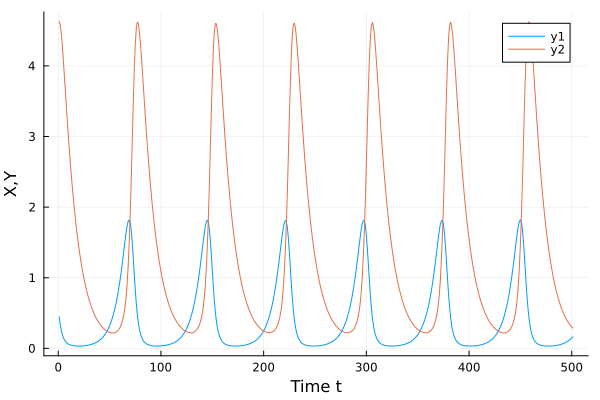

In [3]:
function lotka_volterra(x,p,t)
    α, β, γ, δ = p
    return [α*x[1] - β*x[1]*x[2], -γ*x[2] + δ*x[1]*x[2]]
end

α = 1.3
β = 0.9
γ = 0.8
δ = 1.8
p = Float32.([α, β, γ, δ])
tspan = (0f0, 50f0) # we watch out to really have everything as Float32
dt = 0.1f0

x0 = Float32.([0.44249296, 4.6280594])

prob = ODEProblem(lotka_volterra, x0, tspan, p)
sol = solve(prob, Tsit5(), saveat=dt)

plot(Array(sol)', xlabel="Time t", ylabel="X,Y")

In [7]:
device = MLDataDevices.gpu_device()

# dataloaders directly from the sol object 
#train_data, valid_data = NODEDataloader(sol, 10; dt=dt, valid_set=0.5) 

# dataloaders from array data and time axis seperately 
#train_data, valid_data = NODEDataloader(Array(sol), sol.t, 10; valid_set=0.5) 

(::CPUDevice) (generic function with 1 method)

* We split the data into a training and validation set 
* The Dataloader also splits it into smaller slices each of length `10` and returns pairs $(t, x(t))$ of this length

In [18]:
train_data[1]

(Float32[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], Float32[0.44249296 0.33276716 … 0.06907976 0.05963967; 4.6280594 4.578708 … 3.1837945 2.9731314])

# Now, let's set up a NDE

* Then, we use `Flux` to define a neural network that will be the right hand side of our Neural Differential Equation.
* For this approach, we need to use `Optimisers.destructure` to separate the structure of the network from its parameters.

In [19]:
N_WEIGHTS = 10
nn = Chain(Dense(2, N_WEIGHTS, swish), Dense(N_WEIGHTS, N_WEIGHTS, swish), Dense(N_WEIGHTS, N_WEIGHTS, swish), Dense(N_WEIGHTS, 2)) |> device
p, re_nn = Optimisers.destructure(nn)

(Float32[0.0071681673, 0.19201961, -0.39752966, 0.3144207, -0.07399064, 0.46701682, 0.34694806, 0.4046769, -0.31036955, -0.19594112  …  0.09705163, -0.19654399, -0.13404855, -0.35267058, -0.448146, 0.1130075, -0.29799786, -0.0019386708, 0.0, 0.0], Restructure(Chain, ..., 272))

* `p` are all parameters of the network
* `re_nn(p)` sets up the network again with `p` as its parameters

For our first example we will just have the neural network as the rhs, which we set up like most other differential equations:

In [20]:
function neural_ode(u, p, t)
   return re_nn(p)(u)
end

node_prob = ODEProblem(neural_ode, x0, (Float32(0.), Float32(dt)), p)

ODEProblem with uType Vector{Float32} and tType Float32. In-place: false
Non-trivial mass matrix: false
timespan: (0.0f0, 0.1f0)
u0: 2-element Vector{Float32}:
 0.44249296
 4.6280594

We then define our model that directly returns a trajectory given a sample for our training set.

It saves the ODEProblem and the current parameter values p
It has to save the trajectory at the same time steps and update the parameters and initial conditions to the current state when called
We also save the sensealg that is used in the sensitivity analysis to compute the derivative and potential additional keyword arguments for the solver kwargs
We make Flux.jl/Optimisers.jl aware of the trainable parameters with the trainable function.

In [24]:

"""
    NeuralDE

Model for setting up and training Neural Differential Equations.

# Fields:

* `p` parameter vector
* `prob` DEProblem
* `alg` Algorithm to use for the `solve` command
* `kwargs` any additional keyword arguments that should be handed over (e.g. `sensealg`)

# Constructor

`NeuralDE(prob; alg=Tsit5(), kwargs...)`
"""
struct NeuralDE{P,R,A,K,D} 
    p::P 
    prob::R 
    alg::A
    kwargs::K
    device::D
end 

function NeuralDE(prob; alg=Tsit5(), device=gpu_device(), kwargs...)
    p = prob.p 
    NeuralDE{typeof(p), typeof(prob), typeof(alg), typeof(kwargs), typeof(device)}(p, prob, alg, kwargs, device)
end 

Flux.@layer NeuralDE
Optimisers.trainable(m::NeuralDE) = (p=m.p,)

function (m::NeuralDE)(X, p=m.p)
    (t, x) = X 
    Array(solve(remake(m.prob; tspan=(t[1],t[end]), u0=x[:,1],p=p), m.alg; saveat=t, m.kwargs...))
end

model = NeuralDE(node_prob)
model(train_data[1])

2×10 Matrix{Float32}:
 0.442493  0.45156  0.460594  0.469596  …  0.505287  0.514132  0.522947
 4.62806   4.62766  4.62732   4.62704      4.62644   4.62643   4.62647

In [25]:
node_prob

ODEProblem with uType Vector{Float32} and tType Float32. In-place: false
Non-trivial mass matrix: false
timespan: (0.0f0, 0.1f0)
u0: 2-element Vector{Float32}:
 0.44249296
 4.6280594

We can then, also define a loss function, which is just a sum of least squares:

In [27]:
loss(m, x, y) = Flux.mse(m(x), y) 
loss(model, train_data[1], train_data[1][2]) 

0.47479272f0

For the optimiziation we will use an Adam optimizer from `Flux.jl`, which is a form of a stochastic gradient descent.


In [29]:
η = 1f-3
opt = Optimisers.Adam(η)
opt_state = Optimisers.setup(opt, model)

(p = Leaf(Adam(eta=0.001, beta=(0.9, 0.999), epsilon=1.0e-8), (Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], (0.9, 0.999))), prob = (), alg = (), kwargs = (), device = ())

Then, we can train the model over a number of epochs, decreasing the learning rate every 30 epochs.

In [ ]:
println("starting training...")

for epoch = 1:100
    Flux.train!(model, train_data, opt_state) do m, t, x
        loss(m, (t,x), x)
    end

    if (epoch % 10) == 0  # reduce the learning rate every 10 epochs
        η /= 2
        Optimisers.adjust!(opt_state, η)
    end
    println("epoch $epoch: mean loss = ",mean([loss(model, train_data[i], train_data[i][2]) for i=1:length(train_data)]))  
end

println("... and finished.")

starting training...
epoch 1: mean loss = 1.1993102e-5
epoch 2: mean loss = 1.6847463e-5
epoch 3: mean loss = 1.9656049e-5
epoch 4: mean loss = 3.8393744e-5
epoch 5: mean loss = 0.0002200358
epoch 6: mean loss = 0.00089942914
epoch 7: mean loss = 0.0003861521
epoch 8: mean loss = 5.4920914e-5
epoch 9: mean loss = 3.8073413e-5
epoch 10: mean loss = 2.0966845e-5
epoch 11: mean loss = 2.1288446e-5
epoch 12: mean loss = 6.336426e-5
epoch 13: mean loss = 0.00018498569
epoch 14: mean loss = 0.0007870446
epoch 15: mean loss = 0.00041375917
epoch 16: mean loss = 4.2639385e-5
epoch 17: mean loss = 2.3862243e-5
epoch 18: mean loss = 1.1227815e-5
epoch 19: mean loss = 1.27616895e-5
epoch 20: mean loss = 9.256222e-6
epoch 21: mean loss = 1.119119e-5
epoch 22: mean loss = 8.777301e-6
epoch 23: mean loss = 9.7999055e-6
epoch 24: mean loss = 9.395592e-6
epoch 25: mean loss = 9.527525e-6
epoch 26: mean loss = 1.3015704e-5
epoch 27: mean loss = 2.0773636e-5
epoch 28: mean loss = 5.0560848e-5
epoch 29: 

Now let's plot the results of how the Neural DE performs on the validation set. For that purpose we start with the first point in our valid set as initial condition of our Neural DE and compare it to the ground truth

In [ ]:
plot(valid_data.data', label="Ground Truth") 
plot!(model((valid_data.t, valid_data.data[:,1]))', label="Neural DE")